In [4]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from PINN_XWave_DDP import *


In [19]:
with open('ddp_xwave_model.pkl', 'rb') as f:
    model = pickle.load(f)
print("------pickled model loaded successfully-----")
model=model.to(torch.device("cpu"))
model.eval()

with open('ddp_xwave_means_stds.pkl', 'rb') as f:
    means_stds = pickle.load(f)
means = means_stds['means'].detach().to(torch.device("cpu"))
stds = means_stds['stds'].detach().to(torch.device("cpu"))
print("------pickled means and stds loaded successfully-----")

with open('ddp_xwave_hist.pkl', 'rb') as f:
    history = pickle.load(f)

------pickled model loaded successfully-----
------pickled means and stds loaded successfully-----


In [7]:
def plot_loss_histories(hist):
    "Total Loss, SM Loss, and Physics Loss histories."
    
    plt.figure()
    
    plt.title("PINN Loss Evolution Histories")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (arbitrary units)")
    
    plt.semilogy(hist['sm_loss'], label=r'$\mathcal{L}_{Data}$', color='blue')
    plt.semilogy(hist['physics_loss'], label=r'$\mathcal{L}_{Physics}$', color='green')
    plt.semilogy(hist['loss'], label=r'$\mathcal{L}_{Total}$', color='orange')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    #physics loss components
    
    plt.figure()
    plt.title("PINN Physics Loss Evolution Histories")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (arbitrary units)")
    
    plt.semilogy(hist['gauge_loss'], label=r'$\mathcal{L}_{Gauge}$')
    plt.semilogy(hist['gauss_loss'], label=r'$\mathcal{L}_{Gauss}$')
    plt.semilogy(hist['ampere_x_loss'], label=r'$\mathcal{L}_{ampere_{x}}$')
    plt.semilogy(hist['ampere_y_loss'], label = r'$\mathcal{L}_{ampere_{y}}$')
    plt.semilogy(hist['bdot_curlA_loss'], label=r'$\mathcal{L}_{bdot_curl(A)}$')
    plt.semilogy(hist['momentum_x_loss'], label=r'$\mathcal{L}_{Momentum_x}$')
    plt.semilogy(hist['momentum_y_loss'], label=r'$\mathcal{L}_{Momentum_y}$')
    plt.semilogy(hist['continuity_loss'], label=r'$\mathcal{L}_{continuity}$')    
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig("XWave_loss_hist")
    
    return

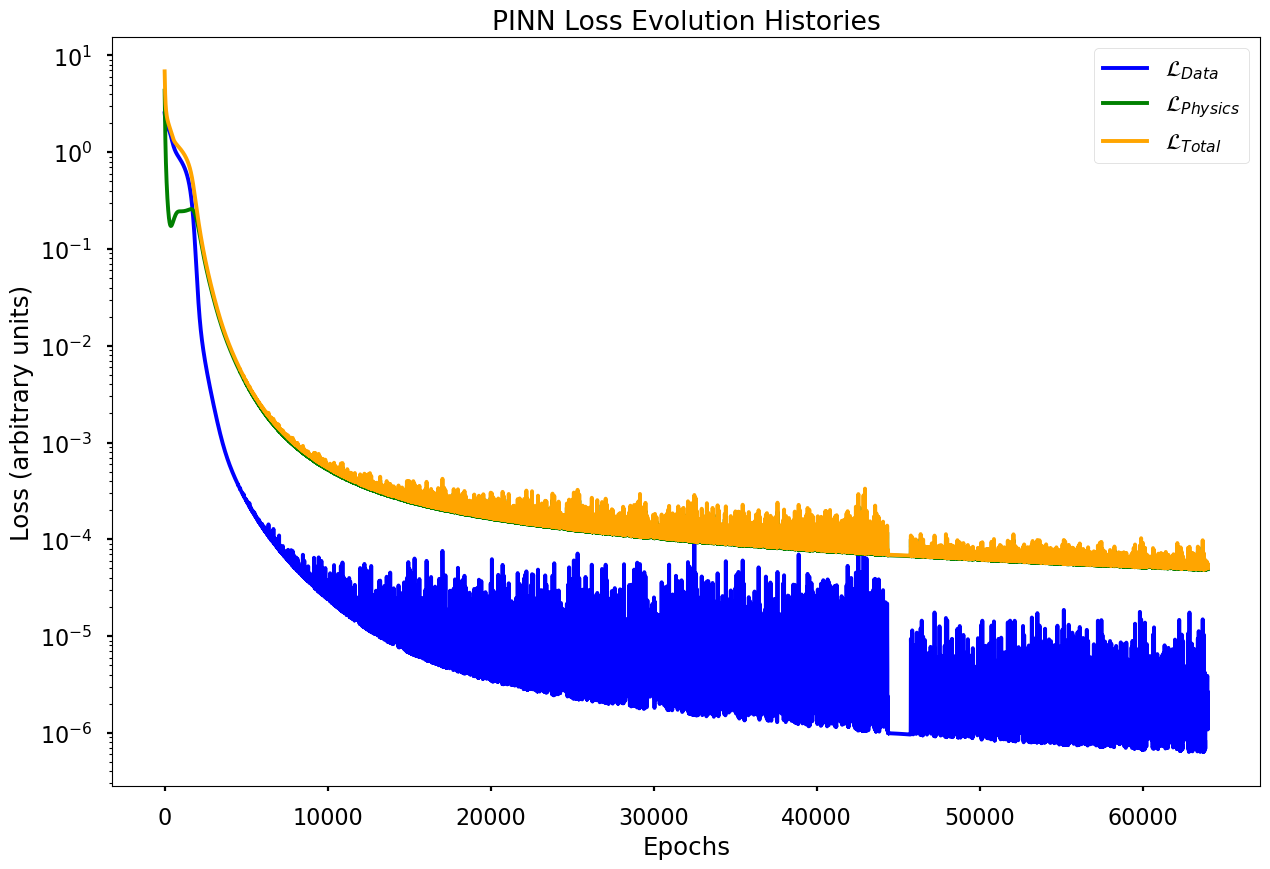

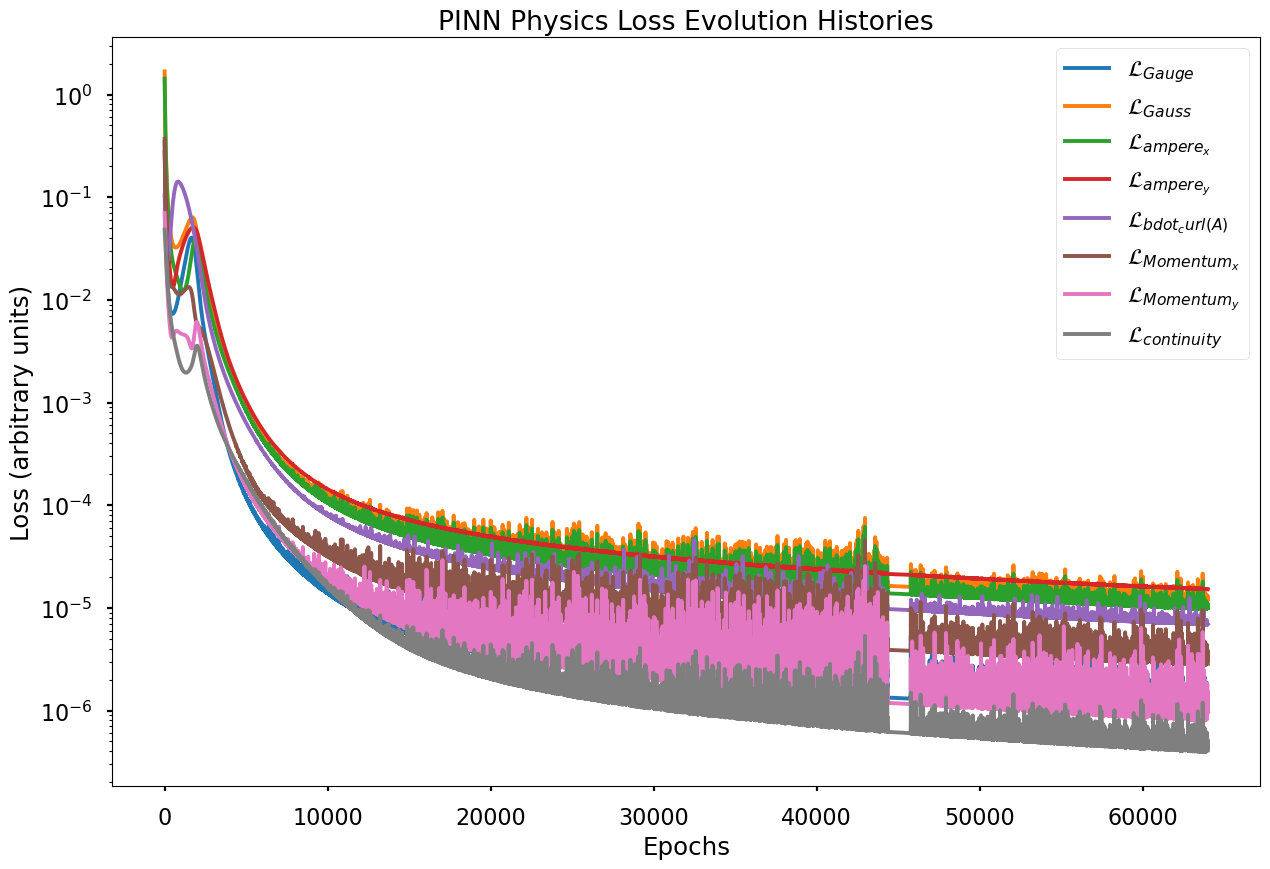

In [8]:
plot_loss_histories(history)

In [12]:
#Global variables physics constants
omega_ce = 2. #B0 is equal to omega_ce in normalized units
B0 = omega_ce  #Background magnetic field in z direction
omega = 1.5
phi_amp = 1.


k = dispersion(omega, omega_ce)
print(f"k = {k:.3f}")

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T
Nt=Nx=2000

k = 1.645


In [22]:
print(next(model.parameters()).device)

cpu


In [16]:
device='cpu'

In [23]:
T = np.linspace(tmin, tmax, Nt)
X = np.linspace(xmin, xmax, Nx)

XX, TT = np.meshgrid(X, T)

TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=False)
XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=False)

cpu cpu cpu
